In [4]:
import pandas as pd
import re

def parse_weather_txt(filepath):
    rows = []
    current_date = None
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # Date header line like "April 16, 2024"
            date_match = re.match(r'^([A-Z][a-z]+ \d{1,2}, \d{4})$', line)
            if date_match:
                current_date = date_match.group(1)
                continue
            
            # Skip column header lines
            if line.startswith('Time'):
                continue
            
            if current_date is None:
                continue
            
            # Strip units from all fields
            clean = line.replace('°C', '').replace('km/h', '').replace('hPa', '') \
                        .replace('mm', '').replace('w/m²', '').replace('%', '') \
                        .replace(',', '')  # thousand separator in pressure
            
            parts = clean.split('\t')
            if len(parts) < 12:
                continue
            
            time_str = parts[0].strip()
            dt = pd.to_datetime(f"{current_date} {time_str}", format='%B %d, %Y %I:%M %p')
            
            rows.append({
                'datetime': dt,
                'temperature': float(parts[1]),
                'dew_point': float(parts[2]),
                'humidity': float(parts[3]),
                'wind_dir': parts[4].strip() if parts[4].strip() else None,
                'speed': float(parts[5]),
                'gust': float(parts[6]),
                'pressure': float(parts[7]),
                'precip_rate': float(parts[8]),
                'precip_accum': float(parts[9]),
                'uv': int(parts[10]),
                'solar': float(parts[11])
            })
    
    df = pd.DataFrame(rows)
    df.set_index('datetime', inplace=True)
    
    # Wind direction to degrees
    wind_dir_map = {
        'North': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
        'East': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
        'South': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
        'West': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
    }
    df['wind_deg'] = df['wind_dir'].map(wind_dir_map)
    
    return df

df = parse_weather_txt('data/weather_data.txt')
df.to_csv('weather_5min.csv')
print(f"Rows: {len(df)} | Range: {df.index.min()} to {df.index.max()}")
print(f"Missing:\n{df.isnull().sum()}")

Rows: 15257 | Range: 2024-04-16 00:04:00 to 2024-06-06 23:59:00
Missing:
temperature       0
dew_point         0
humidity          0
wind_dir        473
speed             0
gust              0
pressure          0
precip_rate       0
precip_accum      0
uv                0
solar             0
wind_deg        473
dtype: int64


In [5]:
import pandas as pd

# Load weather (already parsed)
weather = pd.read_csv('weather_5min.csv', parse_dates=['datetime'], index_col='datetime')

# Load foraging events
events = pd.read_csv('data/aggregated_events.csv', parse_dates=['event_datetime'])

# Bin events into 5-min intervals
events['time_bin'] = events['event_datetime'].dt.floor('5min')

# Aggregate per 5-min bin
event_counts = events.groupby('time_bin').agg(
    total_events=('action', 'size'),
    entries=('action', lambda x: (x == 'Entry').sum()),
    exits=('action', lambda x: (x == 'Exit').sum()),
    unique_nests=('nest', 'nunique'),
    mean_confidence=('ml_confidence', 'mean'),
).rename_axis('datetime')

# Merge with weather
merged = weather.join(event_counts, how='left')

# Fill bins with no events as 0
event_cols = ['total_events', 'entries', 'exits', 'unique_nests']
merged[event_cols] = merged[event_cols].fillna(0).astype(int)
merged['mean_confidence'] = merged['mean_confidence'].fillna(0)

# Add time features for ML
merged['hour'] = merged.index.hour
merged['day_of_week'] = merged.index.dayofweek
merged['is_daytime'] = merged['hour'].between(6, 20).astype(int)

merged.to_csv('weather_foraging_5min.csv')
print(f"Shape: {merged.shape}")
print(f"Events captured: {merged['total_events'].sum()} / {len(events)}")
print(merged[merged['total_events'] > 0].head(10))

Shape: (15257, 20)
Events captured: 0 / 34057
Empty DataFrame
Columns: [temperature, dew_point, humidity, wind_dir, speed, gust, pressure, precip_rate, precip_accum, uv, solar, wind_deg, total_events, entries, exits, unique_nests, mean_confidence, hour, day_of_week, is_daytime]
Index: []


In [8]:
import pandas as pd

df = pd.read_csv('data/nesting_data.csv')

# Parse tube letter and row from nest_code (e.g., "I-A-5" → row="I", letter="A")
df['row'] = df['nest_code'].str.split('-').str[0]
df['letter'] = df['nest_code'].str.split('-').str[1]

# Mapping
frame_offset = {'MT': 0, 'NT': 0, 'MB': 30, 'NB': 30}
row_offset = {'I': 0, 'II': 10, 'III': 20}
letter_pos = {chr(65 + i): i + 1 for i in range(10)}  # A=1 ... J=10

# Compute tube number
df['tube_num'] = df.apply(
    lambda r: frame_offset.get(r['frame_id'], 0) + 
              row_offset.get(r['row'], 0) + 
              letter_pos.get(r['letter'], 0), axis=1
)

# Use existing nest_id where available (as validation), else use computed
df['nest_id_orig'] = pd.to_numeric(df['nest_id'], errors='coerce')
mismatches = df.dropna(subset=['nest_id_orig'])
mismatches = mismatches[mismatches['nest_id_orig'] != mismatches['tube_num']]
if len(mismatches) > 0:
    print(f"WARNING: {len(mismatches)} mismatches between existing nest_id and computed:")
    print(mismatches[['frame_id', 'nest_code', 'nest_id_orig', 'tube_num']])
else:
    print("All existing nest_ids match computed values")

df['tube_num_site'] = df['site'] + '_' + df['tube_num'].astype(str)

# Aggregate per tube per release
tube_summary = df.groupby(['site', 'release', 'tube_num']).agg(
    total_cells=('nest_code', 'size'),
    larvae_cells=('provision', lambda x: x.str.contains('Larvae', na=False).sum()),
    pollen_only=('provision', lambda x: (x == 'Pollen').sum()),
    empty_cells=('provision', lambda x: (x == 'Empty').sum()),
    females=('sex', lambda x: (x == 'F').sum()),
    males=('sex', lambda x: (x == 'M').sum()),
    emerged=('emergence_days', 'count'),
    mean_emergence_days=('emergence_days', 'mean'),
).reset_index()

tube_summary.to_csv('nesting_per_tube.csv', index=False)
print(f"\nTubes with nesting activity: {len(tube_summary)}")
print(f"\nSummary:\n{tube_summary.describe()}")

    frame_id nest_code  nest_id_orig  tube_num
173       MT   II-A-12          21.0        11
174       MT   II-A-11          21.0        11
175       MT   II-A-10          21.0        11
176       MT    II-A-9          21.0        11
177       MT    II-A-8          21.0        11
178       MT    II-A-7          21.0        11
179       MT    II-A-6          21.0        11
180       MT    II-A-5          21.0        11
181       MT    II-A-4          21.0        11
182       MT    II-A-3          21.0        11
183       MT    II-A-2          21.0        11
184       MT    II-A-1          21.0        11

Tubes with nesting activity: 96

Summary:
         release   tube_num  total_cells  larvae_cells  pollen_only  \
count  96.000000  96.000000    96.000000     96.000000    96.000000   
mean    1.562500  30.500000     3.281250      2.104167     1.166667   
std     0.498682  17.769874     3.018201      2.870830     1.120777   
min     1.000000   1.000000     1.000000      0.000000     0.0

/var/folders/r5/48dgr3g12qg3cwmg9f6v0cwc0000gn/T/ipykernel_55802/4002018060.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


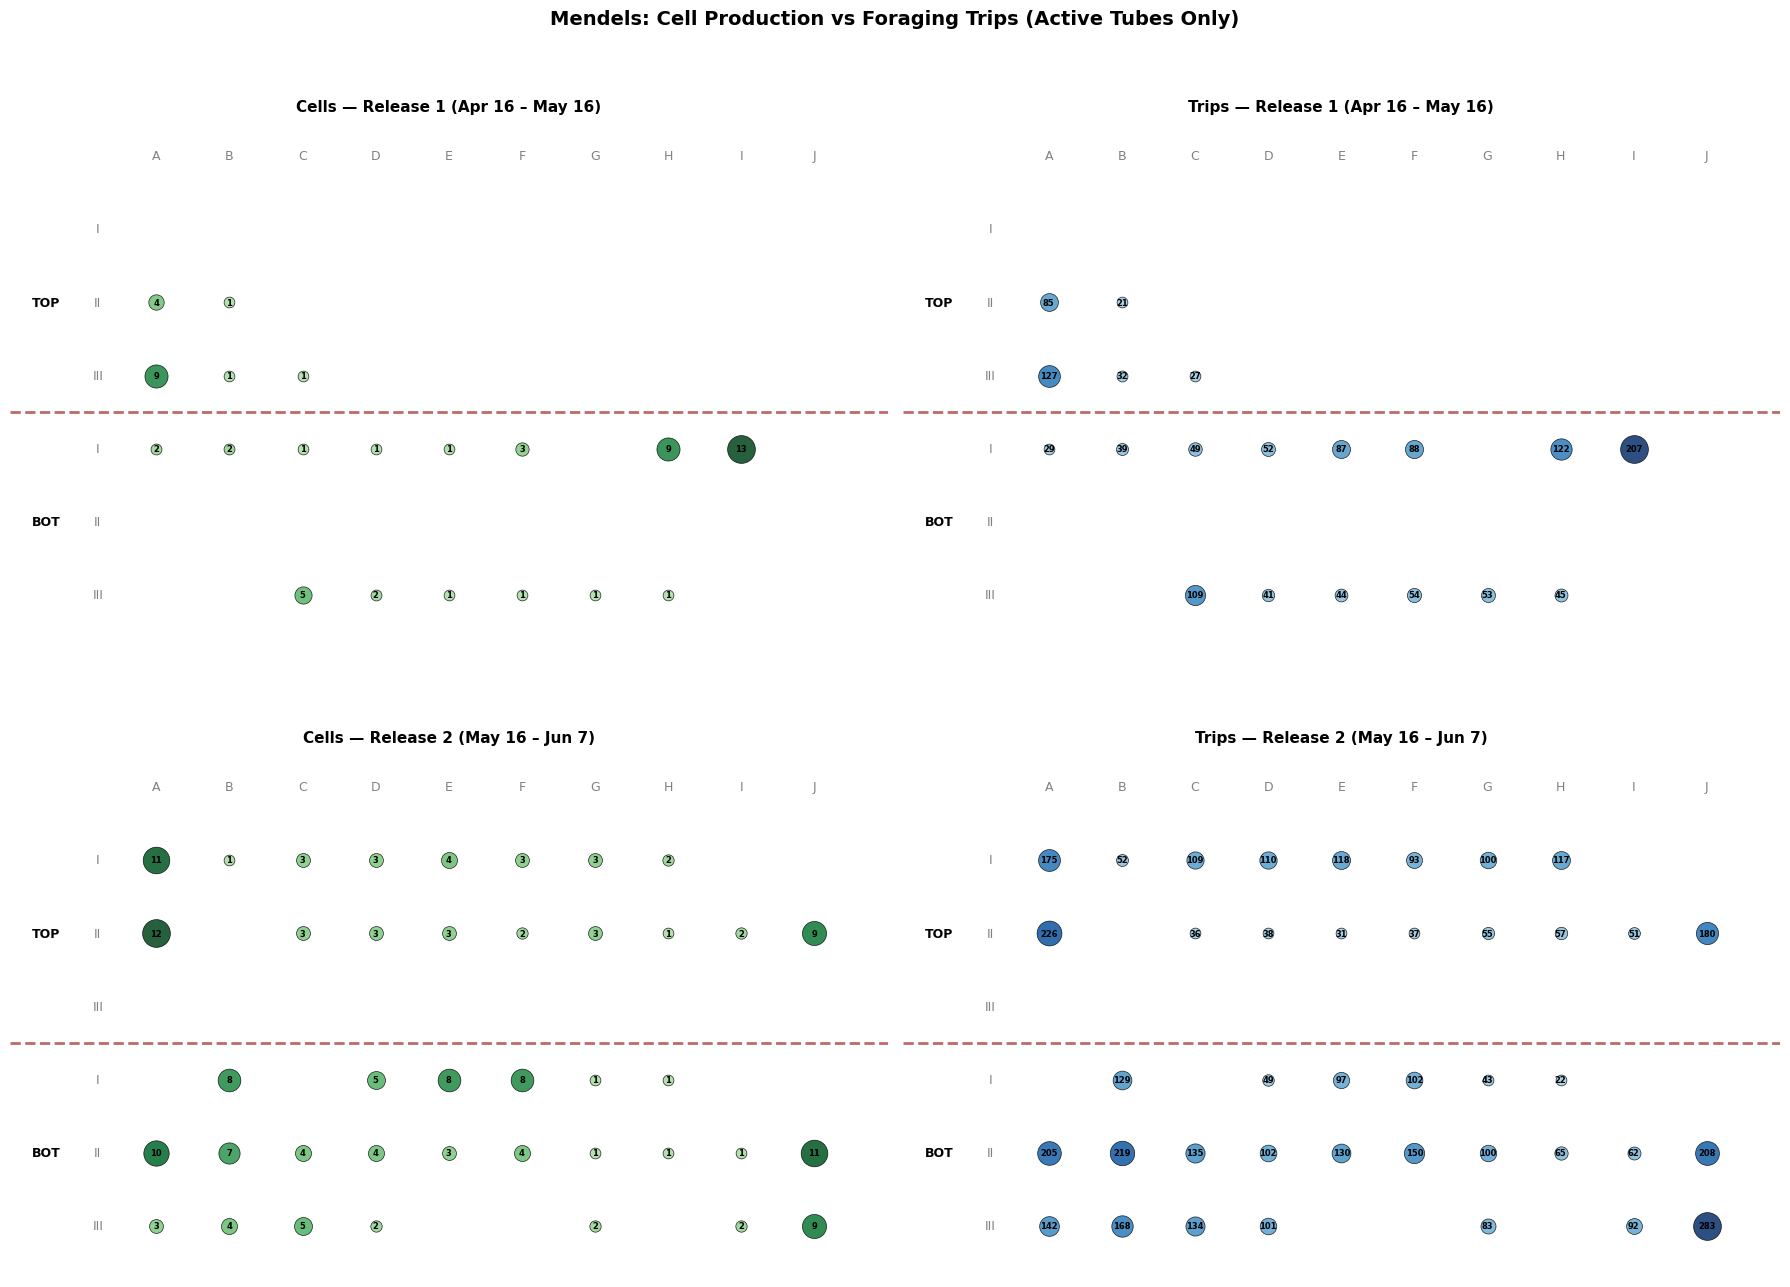

R1: 19 active tubes, 59 cells, 1311 trips
R2: 40 active tubes, 172 cells, 4406 trips


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

raw = pd.read_csv('data/nesting_data.csv')
events = pd.read_csv('data/aggregated_events.csv')

frame_offset = {'MT': 0, 'NT': 0, 'MB': 30, 'NB': 30}
row_offset = {'I': 0, 'II': 10, 'III': 20}
letter_pos = {chr(65 + i): i + 1 for i in range(10)}

raw['row'] = raw['nest_code'].str.split('-').str[0]
raw['letter'] = raw['nest_code'].str.split('-').str[1]
raw['tube_num'] = raw.apply(
    lambda r: frame_offset.get(r['frame_id'], 0) +
              row_offset.get(r['row'], 0) +
              letter_pos.get(r['letter'], 0), axis=1
)
raw_m = raw[raw['site'] == 'Mendels']

r1_tubes = raw_m[raw_m['release'] == 1]['tube_num'].unique()
r2_tubes = raw_m[raw_m['release'] == 2]['tube_num'].unique()

events['event_datetime'] = pd.to_datetime(events['event_datetime'])
events_m = events[events['site'] == 'mendels'].sort_values(['nest', 'event_datetime'])

trips = []
for nest, grp in events_m.groupby('nest'):
    grp = grp.sort_values('event_datetime').reset_index(drop=True)
    i = 0
    while i < len(grp) - 1:
        if grp.loc[i, 'action'] == 'Exit':
            for j in range(i + 1, len(grp)):
                if grp.loc[j, 'action'] == 'Entry':
                    exit_time = grp.loc[i, 'event_datetime']
                    entry_time = grp.loc[j, 'event_datetime']
                    duration = (entry_time - exit_time).total_seconds() / 60
                    trips.append({
                        'nest': nest,
                        'exit_time': exit_time,
                        'entry_time': entry_time,
                        'duration_min': duration
                    })
                    i = j + 1
                    break
            else:
                i += 1
        else:
            i += 1

trips_df = pd.DataFrame(trips)
trips_clean = trips_df[
    (trips_df['duration_min'] > 0.5) &
    (trips_df['duration_min'] < 30) &
    (trips_df['exit_time'].dt.hour.between(6, 20))
].copy()

r1_trips = trips_clean[(trips_clean['exit_time'] >= '2024-04-16') & (trips_clean['exit_time'] < '2024-05-16')]
r2_trips = trips_clean[(trips_clean['exit_time'] >= '2024-05-16') & (trips_clean['exit_time'] < '2024-06-07')]

r1_trip_counts = r1_trips[r1_trips['nest'].isin(r1_tubes)].groupby('nest').size()
r2_trip_counts = r2_trips[r2_trips['nest'].isin(r2_tubes)].groupby('nest').size()

r1_cells = raw_m[raw_m['release'] == 1].groupby('tube_num').size()
r2_cells = raw_m[raw_m['release'] == 2].groupby('tube_num').size()

def tube_to_grid(tube_num):
    grid_row = (tube_num - 1) // 10
    grid_col = (tube_num - 1) % 10
    return grid_row, grid_col

def draw_hotel(ax, tubes, counts, title, cmap_name='Greens'):
    max_val = counts.max() if len(counts) > 0 and counts.max() > 0 else 1
    cmap = plt.cm.get_cmap(cmap_name)

    for tube_num in tubes:
        grow, gcol = tube_to_grid(tube_num)
        y = 5 - grow
        val = counts.get(tube_num, 0)

        if val == 0:
            ax.scatter(gcol, y, s=60, c='#eee', edgecolors='#ccc', linewidths=0.5, zorder=2)
            continue

        norm_val = val / max_val
        size = max(norm_val * 400, 60)
        ax.scatter(gcol, y, s=size, c=[cmap(0.3 + norm_val * 0.7)],
                   edgecolors='k', linewidths=0.5, alpha=0.85, zorder=2)
        ax.text(gcol, y, str(val), ha='center', va='center', fontsize=6, fontweight='bold', zorder=3)

    ax.axhline(y=2.5, color='brown', linewidth=2, linestyle='--', alpha=0.7)
    for r, lbl in [(5, 'I'), (4, 'II'), (3, 'III'), (2, 'I'), (1, 'II'), (0, 'III')]:
        ax.text(-0.8, r, lbl, ha='center', va='center', fontsize=9, color='gray')
    for c in range(10):
        ax.text(c, 6.0, chr(65 + c), ha='center', va='center', fontsize=9, color='gray')
    ax.text(-1.5, 4.0, 'TOP', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(-1.5, 1.0, 'BOT', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(-2, 10)
    ax.set_ylim(-0.7, 6.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Mendels: Cell Production vs Foraging Trips (Active Tubes Only)', fontsize=14, fontweight='bold')

draw_hotel(axes[0, 0], r1_tubes, r1_cells, 'Cells — Release 1 (Apr 16 – May 16)', 'Greens')
draw_hotel(axes[0, 1], r1_tubes, r1_trip_counts, 'Trips — Release 1 (Apr 16 – May 16)', 'Blues')
draw_hotel(axes[1, 0], r2_tubes, r2_cells, 'Cells — Release 2 (May 16 – Jun 7)', 'Greens')
draw_hotel(axes[1, 1], r2_tubes, r2_trip_counts, 'Trips — Release 2 (May 16 – Jun 7)', 'Blues')

plt.tight_layout()
plt.savefig('mendels_cells_vs_trips_active.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"R1: {len(r1_tubes)} active tubes, {r1_cells.sum()} cells, {r1_trip_counts.sum()} trips")
print(f"R2: {len(r2_tubes)} active tubes, {r2_cells.sum()} cells, {r2_trip_counts.sum()} trips")

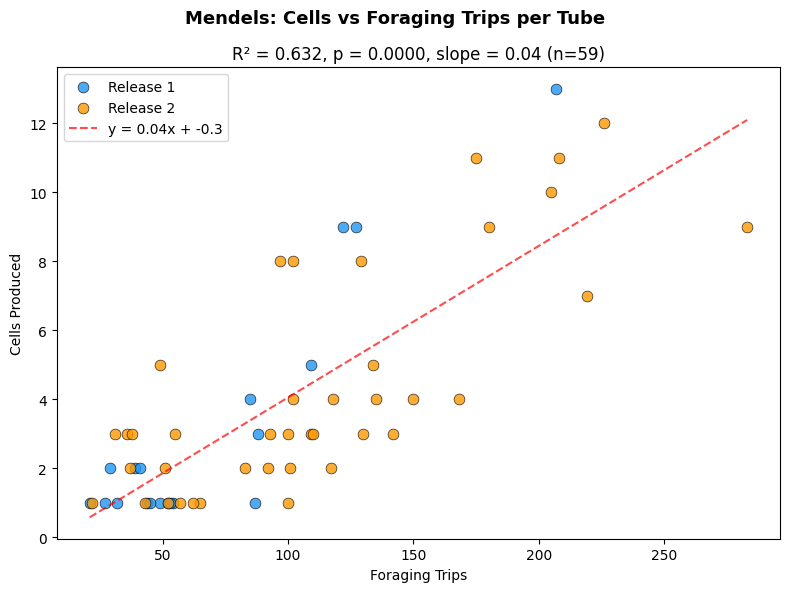

Combined (n=59):
  slope = 0.044 cells/trip (±0.004)
  intercept = -0.34
  R² = 0.632
  p = 0.0000


In [24]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def build_compare(tubes, cells, trips):
    return pd.DataFrame({
        'tube': sorted(tubes),
        'cells': [cells.get(t, 0) for t in sorted(tubes)],
        'trips': [trips.get(t, 0) for t in sorted(tubes)]
    })

r1_df = build_compare(r1_tubes, r1_cells, r1_trip_counts)
r1_df['release'] = 1
r2_df = build_compare(r2_tubes, r2_cells, r2_trip_counts)
r2_df['release'] = 2

combined = pd.concat([r1_df, r2_df], ignore_index=True)

slope, intercept, r_val, p_val, std_err = stats.linregress(combined['trips'], combined['cells'])

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Mendels: Cells vs Foraging Trips per Tube', fontsize=13, fontweight='bold')

ax.scatter(r1_df['trips'], r1_df['cells'], s=60, c='#2196F3', edgecolors='k',
           linewidths=0.5, alpha=0.8, label='Release 1')
ax.scatter(r2_df['trips'], r2_df['cells'], s=60, c='#FF9800', edgecolors='k',
           linewidths=0.5, alpha=0.8, label='Release 2')

x_line = np.linspace(combined['trips'].min(), combined['trips'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='red', alpha=0.7, linewidth=1.5,
        label=f'y = {slope:.2f}x + {intercept:.1f}')

ax.set_xlabel('Foraging Trips')
ax.set_ylabel('Cells Produced')
ax.set_title(f'R² = {r_val**2:.3f}, p = {p_val:.4f}, slope = {slope:.2f} (n={len(combined)})')
ax.legend()

plt.tight_layout()
plt.savefig('mendels_linear_regression_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Combined (n={len(combined)}):")
print(f"  slope = {slope:.3f} cells/trip (±{std_err:.3f})")
print(f"  intercept = {intercept:.2f}")
print(f"  R² = {r_val**2:.3f}")
print(f"  p = {p_val:.4f}")

Total 5-min bins: 9178
Active bins: 1951 (21.3%)
Inactive bins: 7227 (78.7%)
Date range: 2024-04-16 06:00:00 to 2024-06-06 20:55:00
Fold 1: AUC=0.831, n=1529, active=419 (27.4%)
Fold 2: AUC=0.847, n=1529, active=322 (21.1%)
Fold 3: AUC=0.791, n=1529, active=443 (29.0%)
Fold 4: AUC=0.855, n=1529, active=572 (37.4%)
Fold 5: AUC=0.697, n=1529, active=89 (5.8%)

Mean AUC: 0.804 ± 0.058
Pooled AUC: 0.786


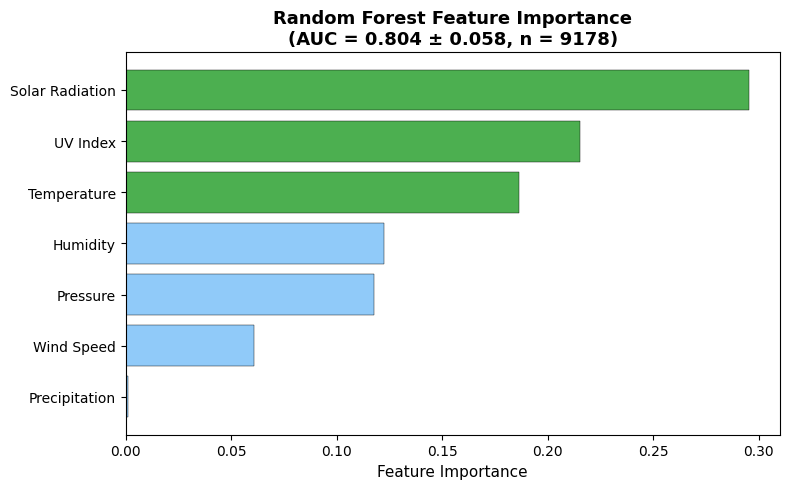

In [70]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

weather = pd.read_csv('data/weather_5min.csv', parse_dates=['datetime'], index_col='datetime')
weather = weather.drop(columns=['wind_dir'], errors='ignore')
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)

trips = pd.read_csv('data/foraging_trips.csv', parse_dates=['exit_time'])
trips['time_bin'] = trips['exit_time'].dt.floor('5min')
trip_counts = trips.groupby('time_bin').size().rename('trips')

merged = weather.join(trip_counts, how='left')
merged['trips'] = merged['trips'].fillna(0).astype(int)
merged = merged[merged.index.hour >= 6]
merged = merged[merged.index.hour <= 20]
merged['active'] = (merged['trips'] > 0).astype(int)

features = ['temperature', 'humidity', 'speed',
            'pressure', 'precip_rate', 'solar', 'uv']

label_map = {
    'temperature': 'Temperature',
    'humidity': 'Humidity',
    'speed': 'Wind Speed',
    'pressure': 'Pressure',
    'precip_rate': 'Precipitation',
    'solar': 'Solar Radiation',
    'uv': 'UV Index',
}

df = merged[features + ['active']].dropna()
X = df[features]
y = df['active']

print(f"Total 5-min bins: {len(df)}")
print(f"Active bins: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Inactive bins: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Date range: {df.index.min()} to {df.index.max()}")

tscv = TimeSeriesSplit(n_splits=5)
all_y_true, all_y_prob = [], []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    rf = RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = rf.predict_proba(X.iloc[test_idx])[:, 1]

    fold_auc = roc_auc_score(y.iloc[test_idx], y_prob)
    fold_aucs.append(fold_auc)
    all_y_true.extend(y.iloc[test_idx])
    all_y_prob.extend(y_prob)

    n_active = y.iloc[test_idx].sum()
    print(f"Fold {fold+1}: AUC={fold_auc:.3f}, n={len(test_idx)}, "
          f"active={n_active} ({n_active/len(test_idx)*100:.1f}%)")

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

print(f"\nMean AUC: {mean_auc:.3f} ± {std_auc:.3f}")
print(f"Pooled AUC: {pooled_auc:.3f}")

rf_final = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_final.fit(X, y)

fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(rf_final.feature_importances_, index=features).sort_values()
labels = [label_map[f] for f in importances.index]
colors = ['#4CAF50' if v > importances.median() else '#90CAF9' for v in importances.values]
ax.barh(labels, importances.values, color=colors, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Random Forest Feature Importance\n(AUC = {mean_auc:.3f} ± {std_auc:.3f}, n = {len(df)})',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

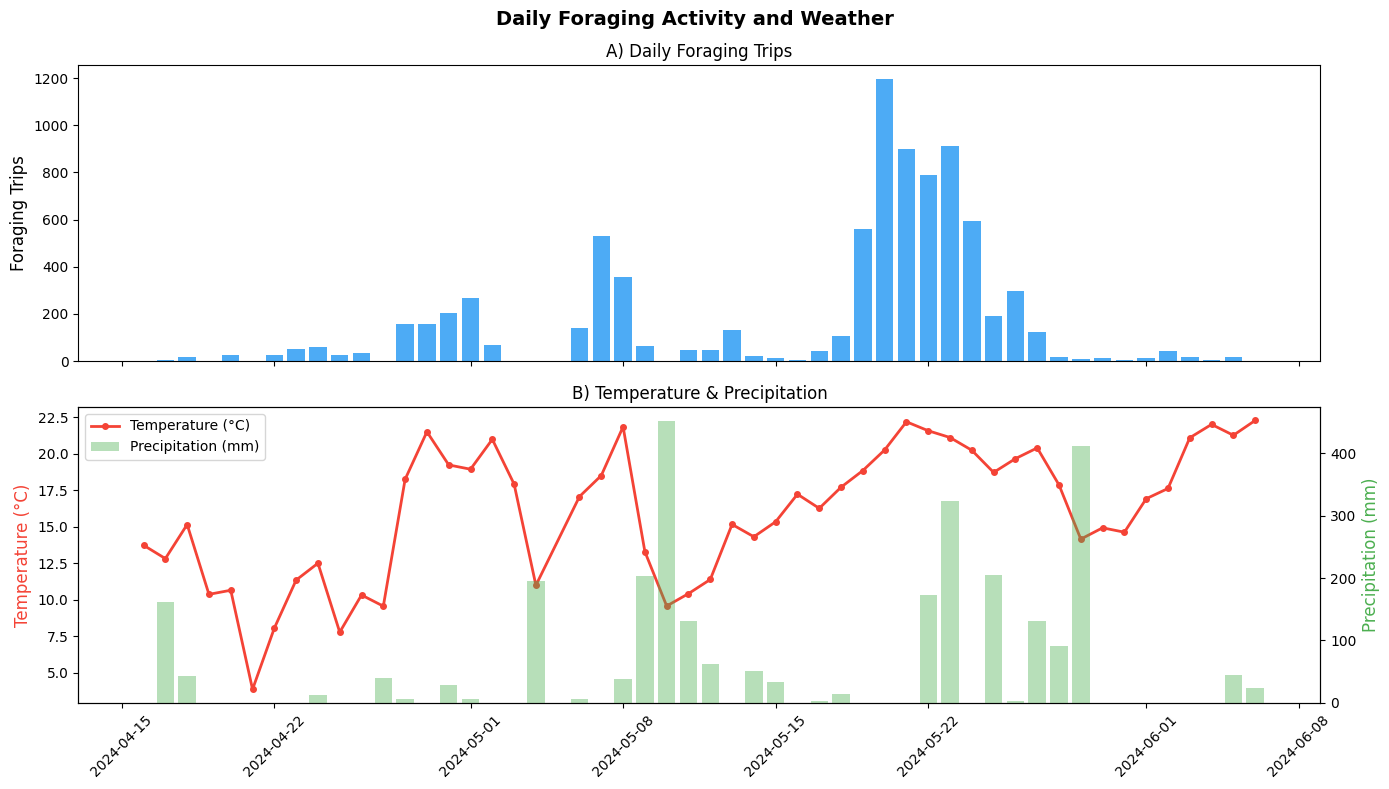

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weather = pd.read_csv('data/weather_5min.csv', parse_dates=['datetime'], index_col='datetime')
weather = weather.drop(columns=['wind_dir'], errors='ignore')
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)

trips = pd.read_csv('data/foraging_trips.csv', parse_dates=['exit_time'])
trips['date'] = trips['exit_time'].dt.normalize()
daily_trips = trips.groupby('date').size().rename('trips')

weather_daily = weather.resample('D').agg({
    'temperature': 'mean',
    'precip_rate': 'sum',
})
weather_daily.columns = ['temperature', 'precip_total']

merged = weather_daily.join(daily_trips, how='left')
merged['trips'] = merged['trips'].fillna(0).astype(int)
merged = merged.dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Daily Foraging Activity and Weather', fontsize=14, fontweight='bold')

# A) Foraging trips
ax1.bar(merged.index, merged['trips'], color='#2196F3', alpha=0.8, width=0.8)
ax1.set_ylabel('Foraging Trips', fontsize=12)
ax1.set_title('A) Daily Foraging Trips', fontsize=12)

# B) Temperature + precipitation
ax2.plot(merged.index, merged['temperature'], color='#F44336', linewidth=2,
         marker='o', markersize=4, label='Temperature (°C)')
ax3 = ax2.twinx()
ax3.bar(merged.index, merged['precip_total'], color='#4CAF50', alpha=0.4,
        width=0.8, label='Precipitation (mm)')
ax2.set_ylabel('Temperature (°C)', fontsize=12, color='#F44336')
ax3.set_ylabel('Precipitation (mm)', fontsize=12, color='#4CAF50')
ax2.set_title('B) Temperature & Precipitation', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('daily_trips_weather.png', dpi=200, bbox_inches='tight')
plt.show()